In [1]:
#  Load data and set up analysis switches
from pathlib import Path

import matplotlib.pyplot as plt
import nibabel as nib
import numpy as np
import pandas as pd
from nilearn import image, plotting
from nilearn.glm.first_level import FirstLevelModel
import fusiproc_utils2 as fu

# -------- dataset paths -------
BASE = Path(
    "/Users/clairenastaskin/Downloads/06a04de1-eecd-7ddb-8000-043c48409bc9"
)
RUN = "pwd.nii"
PWD = BASE / RUN

# -------- analysis switches ----
CONF_USE = {
    "motion_6": False,  # translation/rotation 6 params
    "motion_fsl24": True,  # Friston24 (mutually exclusive with motion_6)
    "extra_fd": False,
    "dvars_stdz": False,
    "tcompcor": False,
}
assert not (CONF_USE["motion_6"] and CONF_USE["motion_fsl24"]), (
    "motion_6 and motion_fsl24 are mutually exclusive"
)

# --- registration reference --------------------------------------------------
REG_REFERENCE = "mean"  # {"mean", "median"}

# --- temporal smoothing ------------------------------------------------------
SMOOTH_METHOD = "boxcar"  # {"none", "boxcar", "savgol"}
SMOOTH_WINDOW = 3  # for boxcar (odd)
SG_PARAMS = {"window": 7, "polyorder": 2}  # Savitzky–Golay (odd)

FD_THRESH = 1.00  # mm
RADIUS_MM = 50.0  # mm for FD sphere

# --- GLM ---------------------------------------------------------------------
REACTION_TIME = 1.0  # s, typical reaction time assumed

# ---------------------------------------------------------------------------
# Build a short suffix that encodes the chosen method (+ key params)
# ---------------------------------------------------------------------------
if SMOOTH_METHOD == "none":
    smooth_tag = "_nosmooth"

elif SMOOTH_METHOD == "boxcar":
    smooth_tag = f"_boxcar{SMOOTH_WINDOW}"

elif SMOOTH_METHOD == "savgol":
    smooth_tag = f"_savgol{SG_PARAMS['window']}-{SG_PARAMS['polyorder']}"

else:
    raise ValueError(f"Unknown SMOOTH_METHOD: {SMOOTH_METHOD}")

In [2]:
# Load ARIA logs and compute volume timing as the mean inter-frame interval
logs_path = Path(BASE, "logs.parquet")
logs_df = pd.read_parquet(logs_path)

print(
    f"Loaded {logs_path.name}: shape {logs_df.shape}, columns: {list(logs_df.columns)}"
)

# Keep a dict view so downstream cells that index by column still work
sidecar = {col: logs_df[col].to_dict() for col in logs_df.columns}

# t_r = mean time difference between consecutive frames (ns -> s)
volume_timing_ns = float(np.mean(np.diff(logs_df["time_ns"].to_numpy())))
volume_timing_s = volume_timing_ns / 1e9
t_r = volume_timing_s
np.save(BASE / "t_r.npy", t_r)
print(f"t_r = {t_r:.6f} s (mean of {len(logs_df) - 1} inter-frame intervals)")

Loaded logs.parquet: shape (788, 1), columns: ['time_ns']
t_r = 1.999946 s (mean of 787 inter-frame intervals)


In [3]:
# # Plot interposer temperature from json file, 'INTERPOSER_TEMP'
# interp_temp = list(sidecar["INTERPOSER_TEMP"].values())
# time_s = np.arange(len(interp_temp)) * t_r

# fig, ax = plt.subplots(figsize=(10, 3))
# ax.plot(time_s, interp_temp)
# ax.set_title("Interposer Temperature")
# ax.set_xlabel("Time (s)")
# ax.set_ylabel("Temperature (°C)")
# plt.tight_layout()
# plt.show()

# # save figure
# save_path = BASE / "interposer_temp.png"
# fig.savefig(save_path)
# print(f"Saved interposer temperature plot to {save_path}")

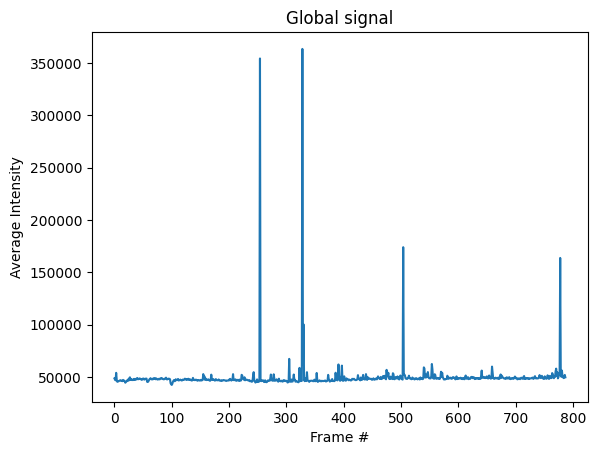

In [3]:
# Global signal and motion detection
data, affine, _ = fu.load_fusi_nifti(PWD)
mask = fu.nan_mask(data)
mask_path = fu.save_nifti(mask.astype(np.uint8), affine, BASE / "mask.nii.gz")

y_lim = None  # If we want to set the y-axis limits

gs = fu.global_signal(data)
fu.plot_global_signal(gs, BASE / "global_signal.png", y_lim)

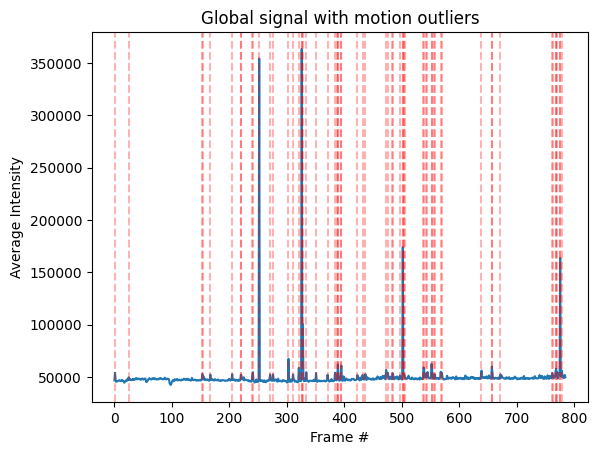

In [4]:
# Keep only the frames that remained after the intensity threshold
skip = {0, 1}
keep_mask = np.ones(len(gs), dtype=bool)
keep_mask[list(skip)] = False
gs_clean = gs[keep_mask]
kept_frames = np.where(keep_mask)[0]

bad_gs, good_gs, fig = fu.detect_motion_via_global(gs_clean, t_r, k=4.0, y_lim=y_lim)
fig.savefig(BASE / "global_signal_with_masked_frame.png")

# Map bad indices back to original frame indices and update skip
skip.update(int(kept_frames[i]) for i in bad_gs)

In [5]:
# ------------------------------------------------------------------
# Rigid registration (reference chosen via REG_REFERENCE in cell [1])
# ------------------------------------------------------------------
registration_path = BASE / "registration"

if not registration_path.exists():
    registration_path.mkdir(exist_ok=True)

    data_f32 = np.where(np.isfinite(data), data, 0).astype(np.float32, copy=False)

    reg, rigid, metric, stop, kept_idx = fu.register_3d_image_stack(
        data_f32,
        reference=REG_REFERENCE,
        spacing=np.linalg.norm(affine[:3, :3], axis=0),
        skip_indices=skip,
        mask=mask,
        verbose=True,
    )

    del data_f32

    # Save the registration outputs
    np.save(registration_path / "reg.npy", reg)
    np.save(registration_path / "rigid.npy", rigid)
    np.save(registration_path / "metric.npy", metric)
    np.save(registration_path / "stop.npy", stop)
    np.save(registration_path / "kept_idx.npy", kept_idx)
    np.save(registration_path / "skip.npy", np.array(sorted(skip), dtype=int))
    # ---- Doppler movie -------------------------------------------------
    html = fu.save_doppler_movie(
        reg, registration_path / "Doppler_movie_after_rigid_registration.mp4"
    )
    html  # renders in Jupyter

else:
    reg = np.load(registration_path / "reg.npy")
    rigid = np.load(registration_path / "rigid.npy")
    metric = np.load(registration_path / "metric.npy")
    stop = np.load(registration_path / "stop.npy")
    kept_idx = np.load(registration_path / "kept_idx.npy")

[frame    2] metric = -8.449711e-01 | stop: RegularStepGradientDescentOptimizerv4: Gradient magnitude tolerance met after 10 iterations. Gradient magnitude (6.13442e-05) is less than gradient magnitude tolerance (0.0001).
[frame    4] metric = -8.185213e-01 | stop: RegularStepGradientDescentOptimizerv4: Gradient magnitude tolerance met after 10 iterations. Gradient magnitude (8.27525e-05) is less than gradient magnitude tolerance (0.0001).
[frame    5] metric = -8.479053e-01 | stop: RegularStepGradientDescentOptimizerv4: Gradient magnitude tolerance met after 10 iterations. Gradient magnitude (3.10488e-06) is less than gradient magnitude tolerance (0.0001).
[frame    6] metric = -8.427776e-01 | stop: RegularStepGradientDescentOptimizerv4: Gradient magnitude tolerance met after 11 iterations. Gradient magnitude (1.67393e-05) is less than gradient magnitude tolerance (0.0001).
[frame    7] metric = -8.439788e-01 | stop: RegularStepGradientDescentOptimizerv4: Gradient magnitude tolerance 

/Users/clairenastaskin/Documents/Anise/Experiments/fusiproc_utils2.py:439: RuntimeWarning: divide by zero encountered in log10
  data_db = 10*np.log10(reg_data)
Animation size has reached 21016432 bytes, exceeding the limit of 20971520.0. If you're sure you want a larger animation embedded, set the animation.embed_limit rc parameter to a larger value (in MB). This and further frames will be dropped.


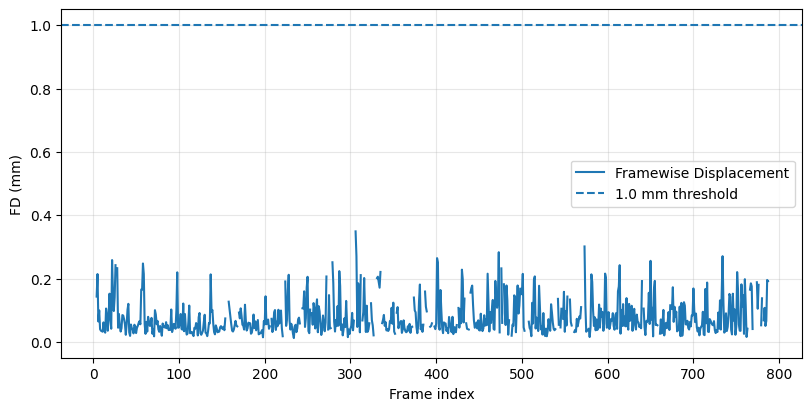

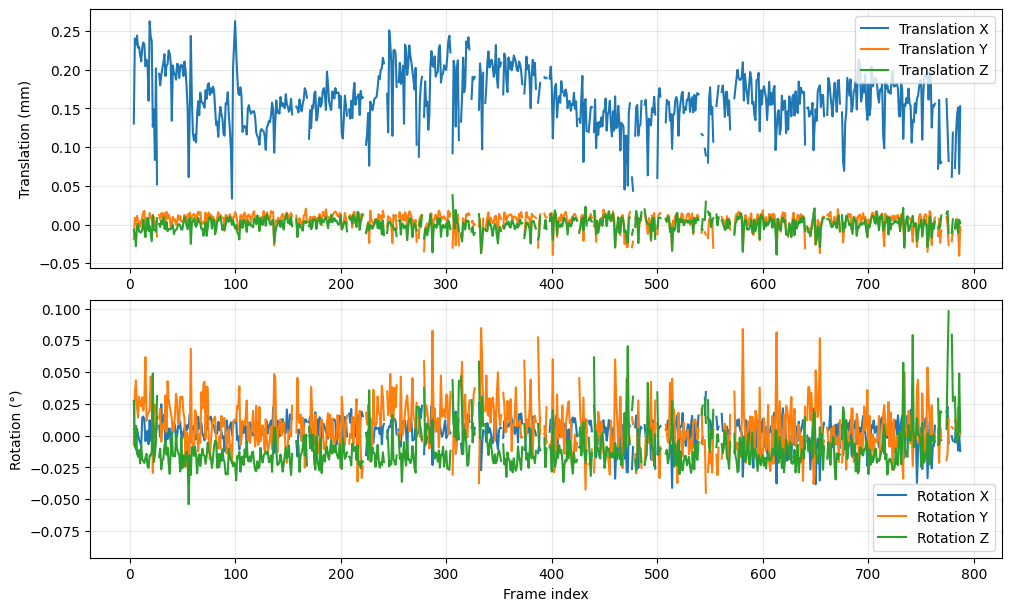

In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# FD outliers, censor list, NaN‑padding
# ─────────────────────────────────────────────────────────────────────────────
n_frames = data.shape[-1]

# 1. FD on the gap‑free series (after GS censoring) ---------------------------
fd = fu.framewise_displacement(rigid, radius_mm=RADIUS_MM)

fd_full = np.full(n_frames, np.nan)
fd_full[kept_idx] = fd

bad_fd = fu.plot_fd(fd_full, FD_THRESH, BASE / "framewise_displacement.png")
fd_tag = f"{FD_THRESH:g}".replace(".", "p")
np.savetxt(BASE / f"fd_over_{fd_tag}_indices.txt", bad_fd, fmt="%d")

# 2. update global censor list ------------------------------------------------
skip.update(int(i) for i in bad_fd)

# 3. remove newly censored frames from the registration outputs ---------------
keep_after_all = [i for i in kept_idx if i not in skip]  # T indices
sel = np.isin(kept_idx, keep_after_all)  # boolean mask

reg_use = reg[..., sel]  # (x,y,z,T)
rigid_use = rigid[:, sel]  # (6,T)
metric_use = metric[sel]  # (T,)
stop_use = [s for s, ok in zip(stop, sel) if ok]

# 4. create full‑length NaN‑padded arrays ------------------------------------
retained = keep_after_all  # same T indices
reg_full, rigid_full, metric_full, stop_full = fu.reinstate_nans(
    reg_use, rigid_use, metric_use, stop_use, n_frames, retained
)

fu.plot_registration_parameters(rigid_full, registration_path / "registration.png")

In [7]:
# ─────────────────────────────────────────────────────────────────────────────
#  DVARS calculation and temporal CompCor (tCompCor) confounds
# ─────────────────────────────────────────────────────────────────────────────

# Save rigid registered data (after registration, before smoothing) as a Nifti file.
# Note: this is the full series (FD-bad frames not yet censored) so DVARS is computed
# on the gap-free temporal sequence.
reg_path = fu.save_nifti(
    reg.astype(np.float32), affine, BASE / "fusi_data_rigid_reg.nii.gz"
)

if CONF_USE["dvars_stdz"]:
    # Calculate standardized DVARS, raw DVARS, and voxelwise DVARS from the registered Nifti
    dvars_stdz, dvars_raw, dvars_vx = fu.calc_dvars(reg_path, mask_path)

    # Plot the standardized DVARS with marked motion outliers
    fu.plot_dvars(dvars_stdz, BASE / "dvars_rigid.png")

# Run tCompCor (temporal CompCor) if selected in configuration.
# This extracts confound timecourses from noise ROIs in the data for denoising.
tc_out = {}
if CONF_USE["tcompcor"]:
    tc_out = fu.run_tcompcor(
        reg_path,
        mask_path,
        BASE / "confounds",
        n_components=6,
        percentile_threshold=0.02,
        tr=t_r,
    )

In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# sample mask, temporal smoothing, confounds (length‑matched)
# ─────────────────────────────────────────────────────────────────────────────
good_all = np.array(retained, dtype=int)  # final list of frames to keep
sample_mask = good_all  # passed to Nilearn
np.save(BASE / "fusi_indices_retained_volumes.npy", sample_mask)
# -- temporal smoothing -------------------------------------------------------
if SMOOTH_METHOD == "none":
    smoothed = reg_full.copy()

elif SMOOTH_METHOD == "boxcar":
    # Apply boxcar (moving average) smoothing: replaces each frame with the average across a sliding window.
    smoothed = fu.boxcar_smooth(reg_full, SMOOTH_WINDOW)

elif SMOOTH_METHOD == "savgol":
    # Apply Savitzky-Golay filter (polynomial smoothing filter). This method smooths the data
    # by fitting successive sub-sets of adjacent frames with a low-degree polynomial.
    smoothed = fu.savgol_smooth(reg_full, **SG_PARAMS)


else:
    raise ValueError(f"Unknown SMOOTH_METHOD “{SMOOTH_METHOD}”")

clean_img = nib.Nifti1Image(np.nan_to_num(smoothed), affine)
clean_img.to_filename(BASE / "fusi_run_clean.nii.gz")
fu.save_nifti(
    np.mean(clean_img.get_fdata(), axis=-1), affine, BASE / "fusi_run_clean_mean.nii.gz"
)

# ------------------------------------------------------------------
# Build confounds – all arrays must have n_frames rows
# ------------------------------------------------------------------
conf_list = []

# ── Motion regressors ──────────────────────────────────────────────────────
motion_full = rigid_full.T.copy()  # (n_frames, 6) – tx,ty,tz,rotx,roty,rotz
motion_full[np.isnan(motion_full)] = 0

if CONF_USE["motion_fsl24"]:
    # --- FSL‑24 construction ---
    # Compute first derivative of motion parameters (frame-to-frame changes)
    deriv = np.vstack([np.zeros((1, 6)), np.diff(motion_full, axis=0)])
    # Compute quadratic terms (squares of parameters and derivatives)
    quad = np.square(np.hstack([motion_full, deriv]))  # 12 quadratic terms

    # Concatenate original parameters, derivatives, and all quadratic terms to obtain 24 regressors
    fsl24 = np.hstack([motion_full, deriv, quad])  # 6 + 6 + 12 = 24
    labels = (
        [f"{p}" for p in ("tx", "ty", "tz", "rotx", "roty", "rotz")]
        + [f"d{p}" for p in ("tx", "ty", "tz", "rotx", "roty", "rotz")]
        + [f"{p}2" for p in ("tx", "ty", "tz", "rotx", "roty", "rotz")]
        + [f"d{p}2" for p in ("tx", "ty", "tz", "rotx", "roty", "rotz")]
    )
    # Package FSL-24 regressors into DataFrame
    conf_list.append(pd.DataFrame(fsl24, columns=labels))

elif CONF_USE["motion_6"]:
    # Use original 6 motion parameters as regressors (translations and rotations)
    conf_list.append(
        pd.DataFrame(motion_full, columns=["tx", "ty", "tz", "rotx", "roty", "rotz"])
    )

# Frame-wise displacement (FD): Measures the sum of absolute values of the differentiated realignment estimates.
# Commonly used to identify volumes with excessive head motion.
if CONF_USE["extra_fd"]:
    fd_col = fd_full.copy()  # already n_frames long
    fd_col[np.isnan(fd_col)] = 0  # replace any NaNs with 0
    conf_list.append(pd.DataFrame(fd_col, columns=["fd"]))

# DVARS (D temporal derivative VARiance): Measures the root mean square variance of the temporal derivative of each brain volume;
# used to identify signal changes due to motion or signal artifacts.

if CONF_USE["dvars_stdz"]:
    dvars_full = np.full(n_frames, np.nan)
    dvars_full[kept_idx] = dvars_stdz  # use kept_idx (not retained_gs)
    dvars_full[np.isnan(dvars_full)] = 0  # replace any NaNs with 0
    conf_list.append(pd.DataFrame(dvars_full, columns=["dvars"]))

# tCompCor (temporal CompCor): Principal component analysis of noise regions (usually WM/CSF) for nuisance regression;
# helps remove physiological or other noise that is not head motion.

if CONF_USE["tcompcor"]:
    comps = pd.read_csv(tc_out["components"], sep="\t").to_numpy()
    tcomp_full = np.full((n_frames, comps.shape[1]), 0.0)
    tcomp_full[kept_idx] = comps  # align with same time base
    conf_list.append(
        pd.DataFrame(
            tcomp_full, columns=[f"tCompCor{i:02d}" for i in range(comps.shape[1])]
        )
    )


# -- final dataframe -----------------------------------------------------------
confounds_df = pd.concat(conf_list, axis=1)

/Users/clairenastaskin/Documents/Anise/Experiments/fusiproc_utils2.py:343: RuntimeWarning: Mean of empty slice
  out[..., t] = np.nanmean(data[..., lo:hi], axis=3)


In [10]:
# Load events once; reused by the GLM cell below.
default_events = BASE / "task_events.tsv"
if default_events.exists():
    task_path = default_events
else:
    candidates = sorted(BASE.glob("*events.tsv"))
    if not candidates:
        raise FileNotFoundError(f"No *events.tsv found in {BASE}")
    if len(candidates) > 1:
        raise RuntimeError(
            f"Ambiguous events file: {len(candidates)} matches in {BASE}: "
            f"{[p.name for p in candidates]}"
        )
    task_path = candidates[0]

events = pd.read_csv(task_path, sep="\t")
print(f"Loaded events from {task_path.name}: {len(events)} rows")
events["trial_type"]

Loaded events from task_events.tsv: 3 rows


0    words
1    words
2    words
Name: trial_type, dtype: object

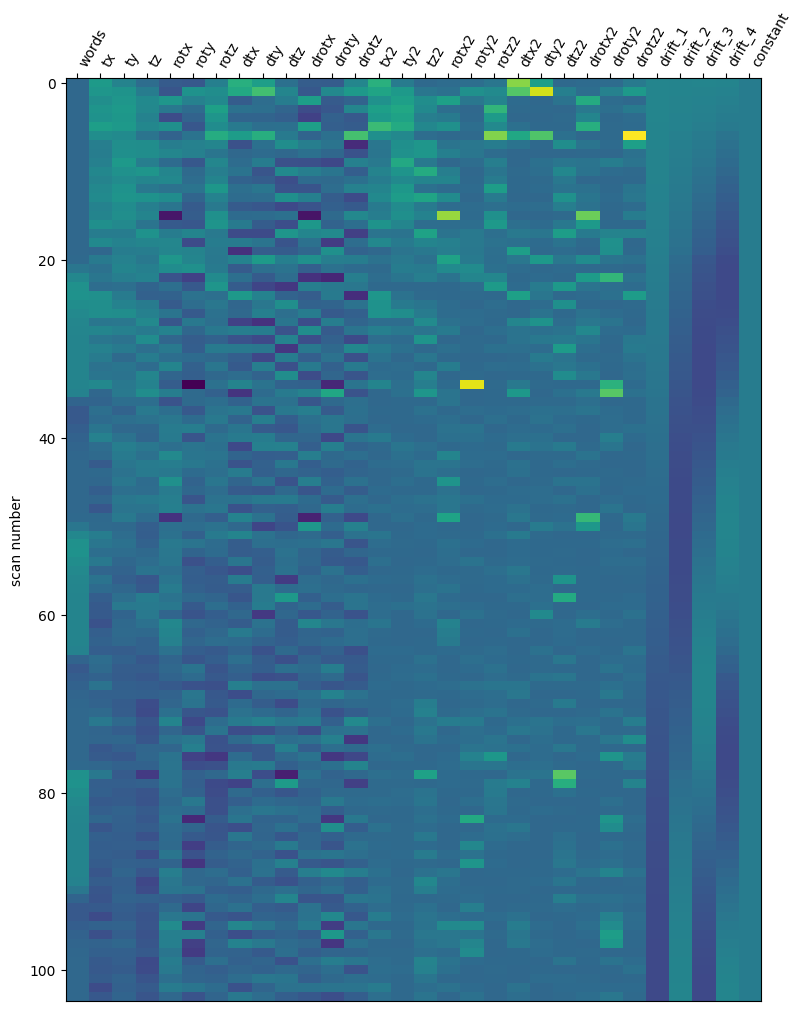

In [11]:
# Shift onsets to align with volume centers (Nilearn assumes onsets at volume start;
# fUSI volume time-stamps mark the start of acquisition, so subtract t_r/2),
# then add the assumed reaction time.
events = events.copy()
events["onset"] -= volume_timing_s / 2
events["onset"] += REACTION_TIME

glm = FirstLevelModel(
    t_r=volume_timing_s,
    hrf_model="glover",
    drift_model="cosine",
    high_pass=0.01,
    noise_model="ar1",
    standardize=True,
    smoothing_fwhm=2,
    mask_img=nib.Nifti1Image(mask.astype(np.uint8), affine),
)


glm, design = fu.build_design_matrix(glm, events, confounds_df, sample_mask, clean_img)
plotting.plot_design_matrix(design)
# Save design matrix to npz file
np.savez(
    BASE / "design_matrix.npz", design_matrix=design.values, column_names=design.columns
)


mean_img = image.mean_img(clean_img, copy_header=True)

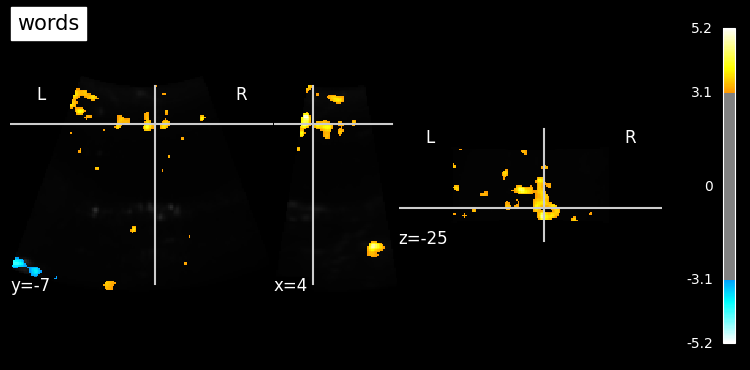

In [12]:
# One-vs-others contrasts: compute and plot per-condition z-maps
NUISANCE_PREFIXES = ("drift_", "tx", "ty", "tz", "rot", "dt", "drot", "constant")


def make_localizer_contrasts(design_matrix):
    """
    Return canonical contrasts plus, for each task condition, a contrast of that
    condition minus the sum of all other task conditions (nuisance regressors excluded).
    """
    contrast_matrix = np.eye(design_matrix.shape[1])
    contrasts = {
        column: contrast_matrix[i] for i, column in enumerate(design_matrix.columns)
    }

    task_names = [
        c for c in design_matrix.columns if not c.startswith(NUISANCE_PREFIXES)
    ]

    for name in task_names:
        others = [n for n in task_names if n != name]
        if not others:
            continue
        vec = contrasts[name].copy()
        for other in others:
            vec -= contrasts[other]
        contrasts[f"{name}-vs-others"] = vec

    return contrasts


first_level_model = glm
design_matrix = first_level_model.design_matrices_[0]
contrasts = make_localizer_contrasts(design_matrix)

for name, vec in contrasts.items():
    if name.startswith(NUISANCE_PREFIXES):
        continue

    zmap = first_level_model.compute_contrast(vec, output_type="z_score")

    # Save zmap as NIfTI file
    nii_out = BASE / f"{name}{smooth_tag}_z_map.nii.gz"
    zmap.to_filename(nii_out)
    png_out = BASE / f"{name}{smooth_tag}_z_map.png"

    plotting.plot_stat_map(
        zmap,
        bg_img=mean_img,
        threshold=3.1,
        display_mode="ortho",
        cut_coords=plotting.find_xyz_cut_coords(zmap, activation_threshold=3.1),
        black_bg=True,
        title=name,
    ).savefig(png_out, dpi=300)

    plotting.show()